In [68]:
from urllib.request import urlopen
from urllib.parse import urlencode, unquote, quote_plus
import urllib
import requests
import json
import pandas as pd


In [69]:
df  = pd.read_csv('./data/201511_202511_기온데이터.csv',encoding='CP949')

In [70]:
df['years'] = df['일시'].str.split('-').str[0].astype(int)
df['month'] = df['일시'].str.split('-').str[1].astype(int)

In [71]:
#7개 시(춘천, 원주, 강릉, 동해, 태백, 속초, 삼척) 
# 11개 군(홍천, 횡성, 영월, 평창, 정선, 철원, 화천, 양구, 인제, 고성, 양양)

In [72]:
df['지점명'].unique()

array(['속초', '북춘천', '철원', '동두천', '파주', '대관령', '춘천', '백령도', '북강릉', '강릉',
       '동해', '서울', '인천', '원주', '울릉도', '수원', '영월', '충주', '서산', '울진', '청주',
       '대전', '추풍령', '안동', '상주', '포항', '군산', '대구', '전주', '울산', '창원', '광주',
       '부산', '통영', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '홍성',
       '서청주', '제주', '고산', '성산', '서귀포', '진주', '강화', '양평', '이천', '인제', '홍천',
       '태백', '정선군', '제천', '보은', '천안', '보령', '부여', '금산', '세종', '부안', '임실',
       '정읍', '남원', '장수', '고창군', '영광군', '김해시', '순창군', '북창원', '양산시', '보성군',
       '강진군', '장흥', '해남', '고흥', '의령군', '함양군', '광양시', '진도군', '봉화', '영주',
       '문경', '청송군', '영덕', '의성', '구미', '영천', '경주시', '거창', '합천', '밀양', '산청',
       '거제', '남해', '북부산'], dtype=object)

In [73]:
gangwon_list = ['춘천', '원주', '강릉', '동해', '태백', '속초', '삼척', '홍천', '횡성', '영월', '평창', '정선', '철원', '화천', '양구', '인제', '고성', '양양']

In [74]:
result = []

for i in df['지점명'].unique():
    if i in gangwon_list:
        result.append(i)

In [75]:
result

['속초', '철원', '춘천', '강릉', '동해', '원주', '영월', '인제', '홍천', '태백']

In [76]:
gangwon_temp_keyword = ['속초', '철원', '춘천', '강릉', '동해', '원주', '영월', '인제', '홍천', '태백']
gangwon_temp_keyword = '|'.join(gangwon_list)

In [77]:
gangwon_2019 = df[(df['지점명'].str.contains(gangwon_temp_keyword))&(df['years']==2019)]
gangwon_2019.isna().sum()
gangwon_2019 = gangwon_2019.dropna(axis=1)
gangwon_2019

,지점,지점명,일시,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),평균현지기압(hPa),평균해면기압(hPa),...,평균상대습도(%),월합강수량(00~24h만)(mm),일최다강수량(mm),평균풍속(m/s),최대풍속(m/s),일조율(%),평균 최저초상온도(°C),평균지면온도(°C),years,month
38,90,속초,2019-01,1.7,6.3,-3.0,12.8,-9.0,1020.4,1022.7,...,35.0,8.7,8.7,1.9,9.9,76.02,-5.6,1.3,2019,1
39,90,속초,2019-02,2.5,6.5,-1.7,15.7,-7.3,1020.0,1022.3,...,49.0,27.6,13.6,1.8,7.0,71.38,-3.0,2.6,2019,2
40,90,속초,2019-03,8.2,13.1,3.1,21.6,-1.4,1012.9,1015.1,...,51.0,44.4,12.3,2.1,10.5,62.93,1.3,8.4,2019,3
41,90,속초,2019-04,11.9,16.6,6.9,25.9,1.3,1011.9,1014.1,...,55.0,80.9,31.2,2.1,11.0,58.27,4.7,13.5,2019,4
42,90,속초,2019-05,19.8,25.0,14.7,34.2,6.5,1007.6,1009.7,...,52.0,5.7,4.0,2.2,9.5,67.06,11.3,24.1,2019,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,217,정선군,2019-08,24.3,30.6,20.1,35.6,15.9,972.9,1007.4,...,74.0,90.2,55.5,1.4,8.7,30.17,19.6,27.4,2019,8
6404,217,정선군,2019-09,19.5,25.7,15.9,31.5,11.0,980.7,1016.0,...,77.0,190.6,52.5,1.2,11.1,30.16,14.8,22.2,2019,9
6405,217,정선군,2019-10,13.3,19.5,8.7,26.1,1.6,983.5,1019.8,...,72.0,71.0,52.0,1.5,9.0,32.42,6.0,15.6,2019,10
6406,217,정선군,2019-11,5.7,12.6,0.8,20.7,-6.0,985.7,1023.2,...,70.0,57.5,21.5,1.5,12.3,43.66,-3.0,7.6,2019,11


In [78]:
elec = pd.read_excel('./data/(2019)시군구별 전력사용량.xlsx', skiprows=2)
elec

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
0,2019,서울특별시,종로구,주택용,24160644,22883203,20039084,20570833,19156656,20278012,22919604,29492782,24800305,20050769,20033320,21855205
1,2019,서울특별시,종로구,일반용,120079512,110317701,93294299,93421543,90325483,98303377,113573453,126148808,110010554,93117616,90242284,106536361
2,2019,서울특별시,종로구,교육용,10204144,9435056,7662196,7881974,6729563,7825646,8631354,9303561,9002269,7322515,7300834,9780051
3,2019,서울특별시,종로구,산업용,6683559,6900078,6731342,7095902,6192349,6372283,6403721,6859148,7011859,5961664,5682268,6223492
4,2019,서울특별시,종로구,농사용,7065,5975,4408,4559,985,754,673,840,741,621,592,3358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,2019,세종특별자치시,세종시,합 계,292024552,266667611,259635613,259582358,250007849,255500866,274188634,289289047,276593028,260172385,263660812,278856325
1830,2019,황해북도,개성시,주택용,10937,9169,9446,7492,6678,6890,8939,10516,8348,7646,9284,10598
1831,2019,황해북도,개성시,일반용,348006,251923,190158,138255,90389,87695,111074,124581,98703,107756,197942,326406
1832,2019,황해북도,개성시,산업용,166936,142981,139741,120540,116713,111140,119631,127520,119255,122606,138500,181140


In [79]:
elec['시군구'] = elec['시군구'].str.replace('구|시|군','',regex=True)
# elec['시군구']


uniq = []

for i in elec['시군구'].unique():
    if i in result:
        uniq.append(i)
    

In [80]:
gangwon_elec_keyword = '|'.join(uniq)
gangwon_elec = elec[elec['시군구'].str.contains(gangwon_elec_keyword)]
gangwon_elec.isna().sum()
gangwon_elec = gangwon_elec.dropna(axis=1)

In [81]:
gangwon_elec

,연도,시도,시군구,계약종별,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
838,2019,강원도,춘천,주택용,36864811,35796185,30916901,32921319,29951151,30132856,31774038,41603059,35307993,30644086,32535612,34475504
839,2019,강원도,춘천,일반용,78224050,74455259,63695174,61967836,58432689,60797970,66962417,76947501,68832266,59973954,61856544,71424987
840,2019,강원도,춘천,교육용,11974594,9757363,8154869,8737438,6071588,5741168,6358127,6344669,7147791,6036226,6285772,9872966
841,2019,강원도,춘천,산업용,18496467,17831946,17641670,18207608,17904530,19122211,20216056,20479881,19005597,19072473,18733483,20168310
842,2019,강원도,춘천,농사용,5938082,5739506,5086385,4989517,3992963,3873156,4130640,5394990,5715214,4379419,5530452,5251627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,2019,강원도,인제,산업용,3373394,3085620,2784679,3002796,2809936,2943218,2836448,2996786,3054846,2987424,3297292,3562656
962,2019,강원도,인제,농사용,2074770,2008001,1806483,2066532,1915329,2071064,2009003,2363860,2831078,2624095,2575882,2228981
963,2019,강원도,인제,가로등,867995,869591,871419,925861,951169,1017306,961512,957494,962875,934945,947321,895933
964,2019,강원도,인제,심 야,11999502,11610280,8767650,7891194,5017160,2804430,1983403,1687005,1789700,3033861,5527807,8178115


In [82]:
gangwon_elec.columns

Index(['연도', '시도', '시군구', '계약종별', '1월', '2월', '3월', '4월', '5월', '6월', '7월',
       '8월', '9월', '10월', '11월', '12월'],
      dtype='object')

In [83]:
df_melted = pd.melt(gangwon_elec, id_vars=['연도','시도','시군구','계약종별'], value_vars=['1월', '2월', '3월', '4월', '5월', '6월', '7월','8월', '9월', '10월', '11월', '12월'], 
                    var_name='month', value_name='전력량')
df_melted
elct_2019 = df_melted[df_melted['계약종별']=='합 계']
elct_2019['month'] = elct_2019['month'].str.replace('월','',regex=True).astype(int)
elct_2019

C:\Users\Playdata\AppData\Local\Temp\ipykernel_20004\3299877252.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elct_2019['month'] = elct_2019['month'].str.replace('월','',regex=True).astype(int)


,연도,시도,시군구,계약종별,month,전력량
7,2019,강원도,춘천,합 계,1,182576706
15,2019,강원도,원주,합 계,1,259351989
23,2019,강원도,강릉,합 계,1,184962779
31,2019,강원도,동해,합 계,1,204776080
39,2019,강원도,태백,합 계,1,32759438
...,...,...,...,...,...,...
927,2019,강원도,속초,합 계,12,45583580
935,2019,강원도,홍천,합 계,12,71395839
943,2019,강원도,영월,합 계,12,103845611
951,2019,강원도,철원,합 계,12,47834137


In [84]:
gangwon_2019_total = pd.merge(gangwon_2019,elct_2019,
                              left_on=['지점명','years','month'],
                              right_on=['시군구','연도','month']
                              ,how='inner')

In [85]:
gangwon_2019_total

,지점,지점명,일시,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),평균현지기압(hPa),평균해면기압(hPa),...,일조율(%),평균 최저초상온도(°C),평균지면온도(°C),years,month,연도,시도,시군구,계약종별,전력량
0,90,속초,2019-01,1.7,6.3,-3.0,12.8,-9.0,1020.4,1022.7,...,76.02,-5.6,1.3,2019,1,2019,강원도,속초,합 계,51680257
1,90,속초,2019-02,2.5,6.5,-1.7,15.7,-7.3,1020.0,1022.3,...,71.38,-3.0,2.6,2019,2,2019,강원도,속초,합 계,49029996
2,90,속초,2019-03,8.2,13.1,3.1,21.6,-1.4,1012.9,1015.1,...,62.93,1.3,8.4,2019,3,2019,강원도,속초,합 계,41663278
3,90,속초,2019-04,11.9,16.6,6.9,25.9,1.3,1011.9,1014.1,...,58.27,4.7,13.5,2019,4,2019,강원도,속초,합 계,40665694
4,90,속초,2019-05,19.8,25.0,14.7,34.2,6.5,1007.6,1009.7,...,67.06,11.3,24.1,2019,5,2019,강원도,속초,합 계,37042950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,216,태백,2019-08,22.5,27.7,18.6,33.0,12.8,928.4,1006.7,...,41.75,18.4,25.7,2019,8,2019,강원도,태백,합 계,23382933
116,216,태백,2019-09,17.6,22.8,13.5,29.2,6.0,935.1,1015.5,...,33.66,14.1,20.5,2019,9,2019,강원도,태백,합 계,22562952
117,216,태백,2019-10,11.5,16.9,6.5,23.7,-1.1,936.5,1019.1,...,33.92,5.0,13.0,2019,10,2019,강원도,태백,합 계,23030697
118,216,태백,2019-11,4.8,11.3,-0.6,18.4,-6.5,937.2,1022.1,...,45.68,-3.3,4.1,2019,11,2019,강원도,태백,합 계,25833436


In [86]:
input = gangwon_2019_total[['전력량','평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)','최저기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)','월합강수량(00~24h만)(mm)', '일최다강수량(mm)', '평균풍속(m/s)', '최대풍속(m/s)', '일조율(%)','평균 최저초상온도(°C)', '평균지면온도(°C)']]
# elct_2019.columns

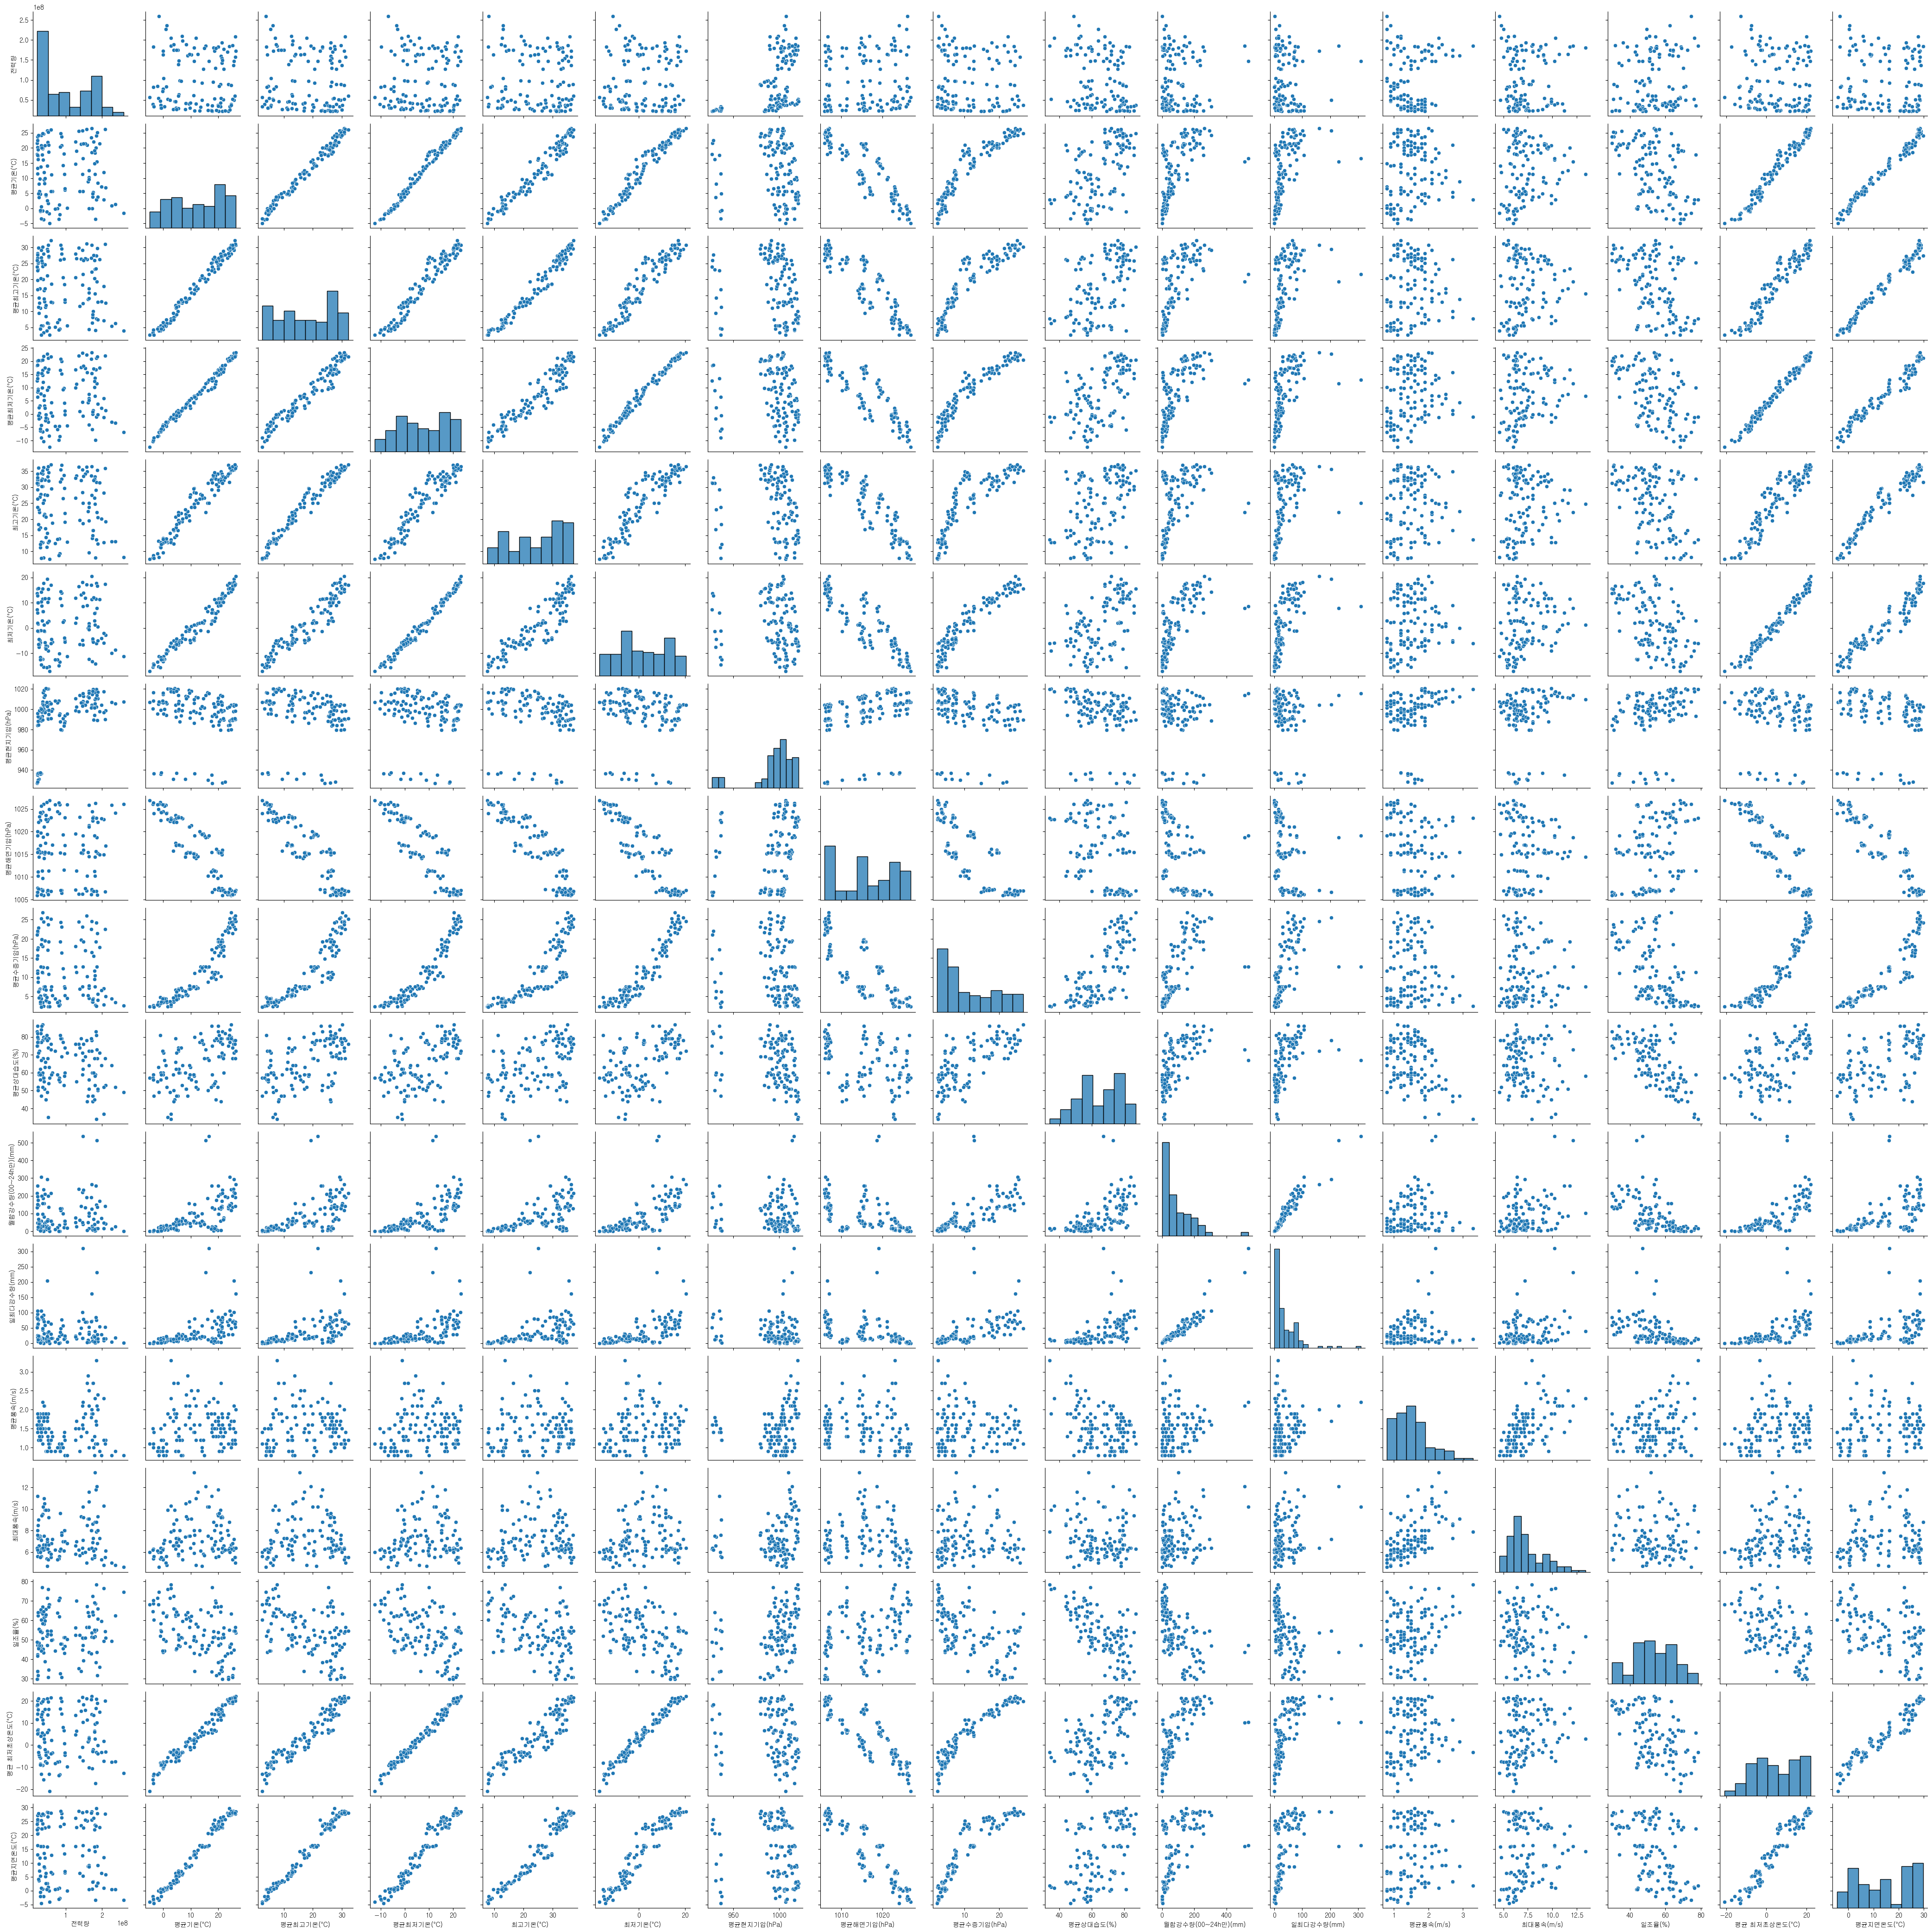

In [87]:
# 한글폰트 사용을 위한 설정
import matplotlib
import matplotlib.font_manager as fm

font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

import seaborn as sns
sns.pairplot(input)

<Axes: >

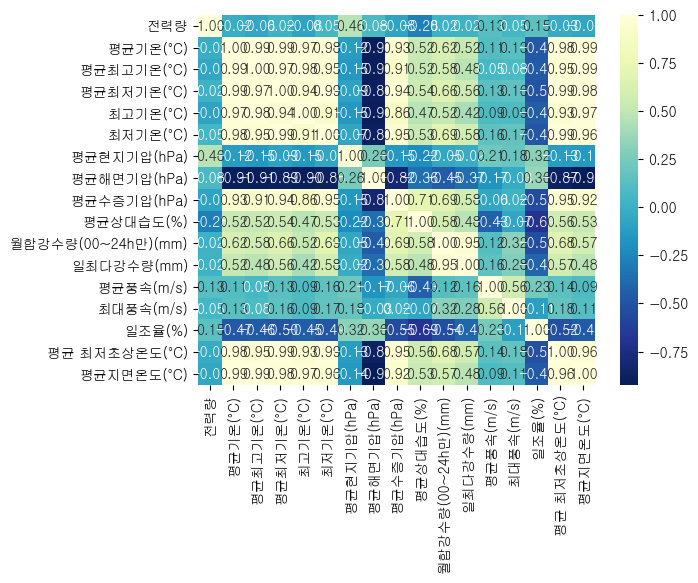

In [88]:
# 상관계수 행렬 생성
corr_matrix = input.corr(numeric_only=True)
corr_matrix
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu_r')

In [89]:
corr_matrix

,전력량,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),일최다강수량(mm),평균풍속(m/s),최대풍속(m/s),일조율(%),평균 최저초상온도(°C),평균지면온도(°C)
전력량,1.000000,-0.015721,-0.062064,0.019101,-0.083824,0.051228,0.462816,0.076093,-0.078084,-0.280333,0.015923,0.020676,0.127256,0.052584,0.150370,-0.031193,-0.055032
평균기온(°C),-0.015721,1.000000,0.991377,0.992430,0.970870,0.976904,-0.120452,-0.908703,0.929074,0.520050,0.619016,0.518194,0.108863,0.129524,-0.471814,0.979714,0.991680
평균최고기온(°C),-0.062064,0.991377,1.000000,0.970091,0.983055,0.948464,-0.151599,-0.907216,0.909618,0.518142,0.575548,0.477828,0.054265,0.079379,-0.457497,0.954129,0.990256
평균최저기온(°C),0.019101,0.992430,0.970091,1.000000,0.943895,0.991066,-0.094953,-0.885803,0.944551,0.544639,0.659854,0.555597,0.130719,0.157695,-0.501357,0.992224,0.976652
최고기온(°C),-0.083824,0.970870,0.983055,0.943895,1.000000,0.909792,-0.151573,-0.901920,0.859486,0.474179,0.515443,0.416360,0.087746,0.087334,-0.448382,0.926182,0.973781
최저기온(°C),0.051228,0.976904,0.948464,0.991066,0.909792,1.000000,-0.072822,-0.880818,0.946325,0.531068,0.685710,0.584078,0.155074,0.174801,-0.485246,0.986186,0.956751
평균현지기압(hPa),0.462816,-0.120452,-0.151599,-0.094953,-0.151573,-0.072822,1.000000,0.257083,-0.154026,-0.222813,-0.051685,-0.023814,0.214471,0.184536,0.321016,-0.128724,-0.143229
평균해면기압(hPa),0.076093,-0.908703,-0.907216,-0.885803,-0.901920,-0.880818,0.257083,1.000000,-0.822299,-0.357807,-0.453439,-0.371259,-0.174765,-0.032726,0.358306,-0.873422,-0.922131
평균수증기압(hPa),-0.078084,0.929074,0.909618,0.944551,0.859486,0.946325,-0.154026,-0.822299,1.000000,0.712906,0.694221,0.576784,-0.058213,0.022340,-0.550488,0.948397,0.916312
평균상대습도(%),-0.280333,0.520050,0.518142,0.544639,0.474179,0.531068,-0.222813,-0.357807,0.712906,1.000000,0.577274,0.476012,-0.432694,-0.069280,-0.687172,0.564912,0.526598


In [90]:
selected_cols = [
    '평균기온(°C)',
    '평균현지기압(hPa)',
    '평균해면기압(hPa)',
    '평균수증기압(hPa)',
    '평균상대습도(%)',
    '월합강수량(00~24h만)(mm)',
    '일최다강수량(mm)',
    '평균풍속(m/s)',
    '평균 최저초상온도(°C)',
    '평균지면온도(°C)'
]

In [91]:
input.columns

Index(['전력량', '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '일최다강수량(mm)', '평균풍속(m/s)', '최대풍속(m/s)', '일조율(%)',
       '평균 최저초상온도(°C)', '평균지면온도(°C)'],
      dtype='object')

In [92]:
X = input[['평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '일최다강수량(mm)', '평균풍속(m/s)', '최대풍속(m/s)', '일조율(%)',
       '평균 최저초상온도(°C)', '평균지면온도(°C)']]
y = input[['전력량']]

In [ ]:
#https://scikit-learn.org/stable/modules/partial_dependence.html

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)
# 랜덤 포레스트
rf_clf = RandomForestClassifier(
    n_estimators=5,
    max_features='sqrt',  # 특성의 일부만 사용
    random_state=42, bootstrap=True
)
rf_clf.fit(X_train, y_train)
print("Random Forest Accuracy:", rf_clf.score(X_test, y_test))

Random Forest Accuracy: 0.0


c:\Users\Playdata\anaconda3\envs\mlstudy_env\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Playdata\anaconda3\envs\mlstudy_env\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Playdata\anaconda3\envs\mlstudy_env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\Playdata\anaconda3\envs\mlstudy_env\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes 

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42
)

tree = DecisionTreeRegressor(
    max_depth=4, random_state=42          # 해석 가능성 확보

)

tree.fit(X_train, y_train)
print(tree.score(y_test,))

import pandas as pd

feature_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance
for i in range(tree.tree_.node_count):
    f = tree.tree_.feature[i]
    t = tree.tree_.threshold[i]

    if f != -2:
        print(
            f"Node {i}: {X.columns[f]} ≤ {round(t, 2)}"
        )

TypeError: RegressorMixin.score() missing 1 required positional argument: 'y'

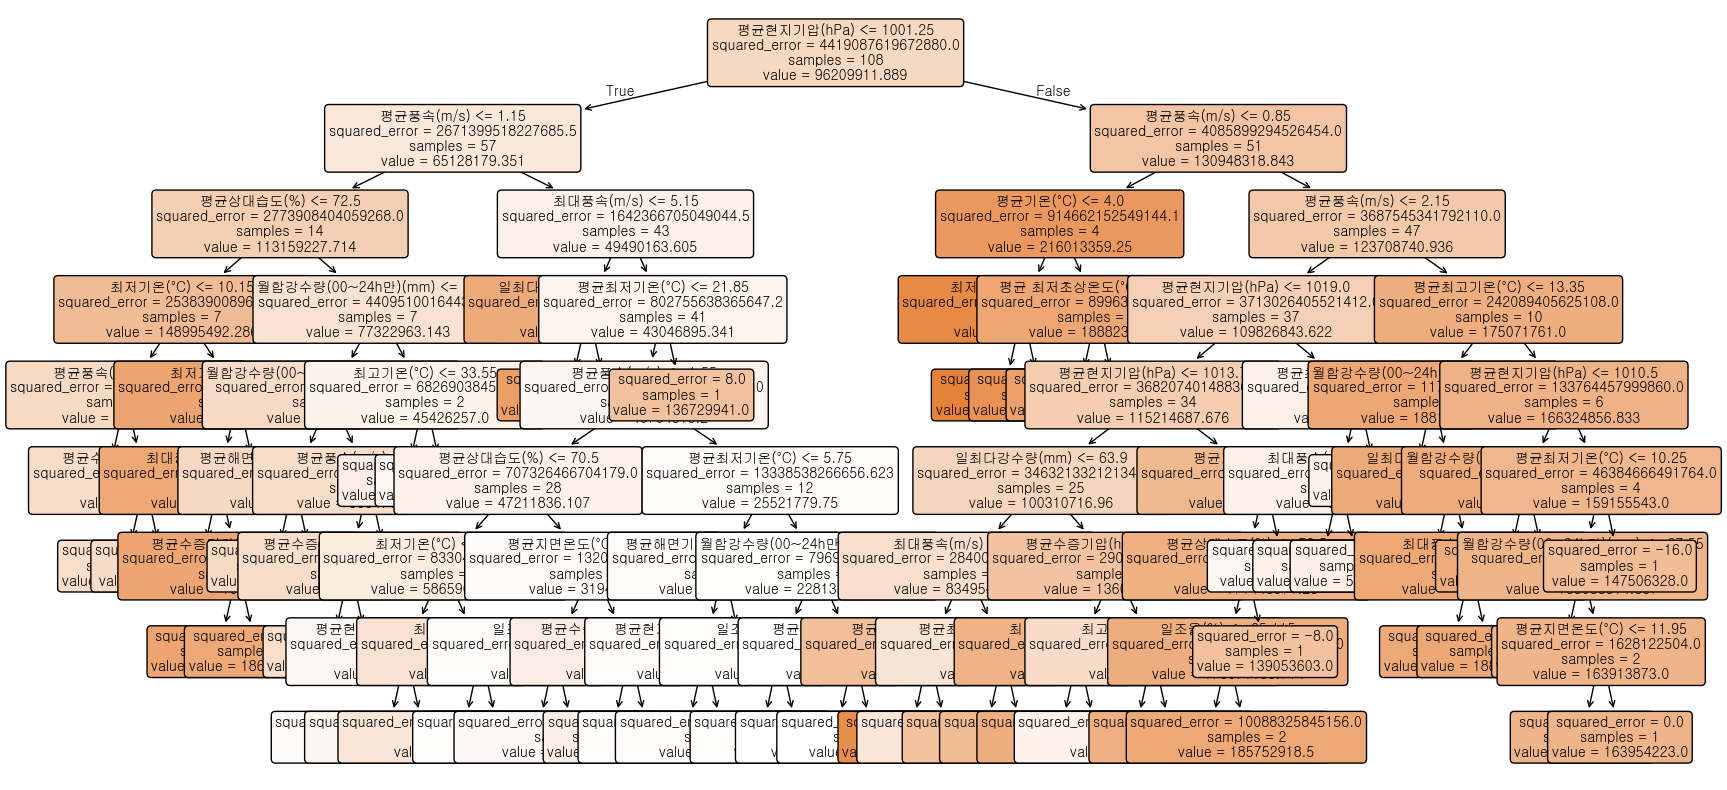

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

1. 연구 목적 및 분석 개요

본 연구의 목적은 전력 사용량에 영향을 미치는 기상 요인을 파악하고, 해당 영향이 단순한 선형 관계인지 혹은 특정 조건에서 변화하는 비선형 구조를 가지는지를 분석하는 데 있다. 이를 위해 기초적인 관계 파악을 위한 상관관계 분석과 함께, 변수 간 비선형 및 조건부 관계를 설명할 수 있는 결정트리 기반 회귀 분석을 수행하였다.

2. 상관관계 분석

전력 사용량과 기상 변수 간의 기초적인 관계를 파악하기 위해 피어슨 상관계수(Pearson correlation coefficient)를 활용한 상관관계 분석을 실시하였다. 분석 대상 변수는 평균기온, 평균현지기압, 평균상대습도, 평균풍속, 일조율, 강수량 등 전력 수요에 이론적으로 영향을 미칠 것으로 예상되는 기상 요인으로 구성하였다.

분석 결과, 전력 사용량과 평균기온, 최고기온, 최저기온 간의 상관계수는 절댓값 0.1 이하로 나타나 전반적으로 약한 선형 관계를 보였다. 이는 기온 변화가 전력 사용량에 영향을 미치지 않는다는 의미라기보다는, 그 영향이 단순한 직선 관계로 설명되기 어렵다는 점을 시사한다.

반면, 평균현지기압은 전력 사용량과 약 0.33의 양(+)의 상관관계를 보였으며, 평균상대습도는 약 -0.29의 음(-)의 상관관계를 나타냈다. 평균풍속 역시 약한 수준이지만 양의 상관관계를 보여, 일부 기상 변수는 전력 사용량과 일정 수준의 연관성을 가지는 것으로 확인되었다.

3. 상관관계 분석의 한계

피어슨 상관계수는 두 변수 간의 선형 관계만을 측정하는 지표로, 특정 임계값을 기준으로 전력 사용량이 급격히 변하는 경우나 변수 간 상호작용 효과를 반영하지 못하는 한계가 있다. 특히 전력 사용량은 냉·난방 기기의 사용 여부가 전환되는 시점에서 불연속적으로 변화할 가능성이 높아, 단순 상관관계 분석만으로는 이러한 구조를 충분히 설명하기 어렵다.

따라서 상관관계 분석 결과에서 기온과 전력 사용량 간의 관계가 약하게 나타났다고 하여 기온의 영향이 없다고 단정하기보다는, 보다 유연한 분석 기법을 통해 비선형적·조건부 관계를 추가적으로 검토할 필요가 있다.

4. 설명 변수 선정 기준

본 연구에서는 전력 사용량에 직접적인 영향을 미칠 것으로 판단되는 기상 요인을 중심으로 설명 변수를 선정하였다. 변수 선택 기준은 다음 세 가지로 설정하였다.

첫째, 전력 수요 이론적 관점에서 냉·난방, 제습, 조명 등 전력 사용 행태와 직접적으로 연관된 변수만을 포함하였다. 둘째, 유사한 정보를 제공하는 변수 간 중복을 최소화하기 위해 기온 관련 변수 중 평균기온을 대표 변수로 선정하였다. 셋째, 분석 결과의 해석 가능성을 고려하여, 명확한 임계값 해석이 가능한 변수를 우선적으로 선택하였다.

이에 따라 본 연구의 주요 설명 변수는 기온, 기압, 습도, 풍속, 일조율, 강수량으로 구성하였으며, 연도(years) 및 월(month)과 같은 시간 변수는 원인 해석의 명확성을 저해할 수 있어 주요 분석에서는 제외하였다.

5. 결정트리 회귀 분석

상관관계 분석의 한계를 보완하고 전력 사용량의 비선형 구조를 분석하기 위해 결정트리 기반 회귀모형을 적용하였다. 결정트리 회귀는 설명 변수를 기준으로 데이터를 반복적으로 분할하여 각 구간에서의 전력 사용량 평균을 추정함으로써, 변수의 임계값에 따른 변화 구조를 직관적으로 파악할 수 있는 장점을 가진다.

분석 결과, 전력 사용량을 분기하는 가장 중요한 변수는 평균현지기압으로 나타났으며, 약 1000hPa 전후를 기준으로 전력 사용 패턴이 뚜렷하게 구분되었다. 이후 평균풍속과 평균상대습도 등이 추가적인 분기 기준으로 작용하여, 전력 사용량이 단일 변수의 변화보다는 여러 기상 조건의 조합에 따라 구간적으로 변화하는 구조를 보였다.

특히 기온 변수는 트리의 초기 분기에서는 상대적으로 낮은 중요도를 보였으나, 특정 저온 구간에서 추가적인 분기 기준으로 활용되었다. 이는 기온의 영향이 전력 사용량 전반에 걸쳐 선형적으로 작용하기보다는, 한파와 같은 극단적 조건에서 선택적으로 나타남을 시사한다.

6. 상관관계 분석과 결정트리 결과의 종합 해석

상관관계 분석에서는 전력 사용량과 기온 간의 선형 관계가 약하게 나타났으나, 결정트리 회귀 분석 결과 기온은 특정 임계 구간에서 전력 사용량을 변화시키는 요인으로 작용함이 확인되었다. 이는 전력 수요가 기온의 점진적 변화보다는 냉·난방 사용 여부가 전환되는 조건에서 비선형적으로 반응한다는 점을 의미한다.

또한 평균현지기압, 풍속, 습도 등은 상관관계 분석과 결정트리 분석 모두에서 전력 사용량과의 연관성이 확인되어, 해당 변수들이 전력 사용 패턴을 설명하는 주요 기상 요인임을 뒷받침한다. 따라서 두 분석 방법은 서로 모순되지 않으며, 상관관계 분석은 전반적인 선형 경향을, 결정트리 회귀 분석은 임계값 기반의 조건부 구조를 설명하는 보완적 관계에 있다고 판단된다.

7. 결론

본 연구에서는 전력 사용량과 기상 변수 간의 관계를 분석하기 위해 상관관계 분석과 결정트리 회귀 분석을 병행하였다. 그 결과 전력 사용량은 단순한 선형 구조보다는 특정 기상 조건의 임계값에 따라 구간적으로 변화하는 비선형적 특성을 가지는 것으로 확인되었다.

특히 기온은 상관관계 분석에서는 영향이 약하게 나타났으나, 결정트리 분석을 통해 극단적인 기상 조건에서 전력 사용량에 의미 있는 영향을 미치는 요인임이 확인되었다. 이는 전력 수요 분석에서 단일 분석 기법에 의존하기보다, 여러 방법을 결합한 다각적 접근의 필요성을 시사한다.